# 1 - Data Preprocessing

Rows dropped (NaN/Inf): 0
  Normal/Benign       :  358,332  (80.00%)
  Exploits            :   30,951  (6.91%)
  Fuzzers             :   29,613  (6.61%)
  Reconnaissance      :   16,735  (3.74%)
  Generic             :    4,632  (1.03%)
  DoS                 :    4,467  (1.00%)
  Shellcode           :    2,102  (0.47%)
  Backdoor            :      452  (0.10%)
  Analysis            :      385  (0.09%)
  Worms               :      246  (0.05%)


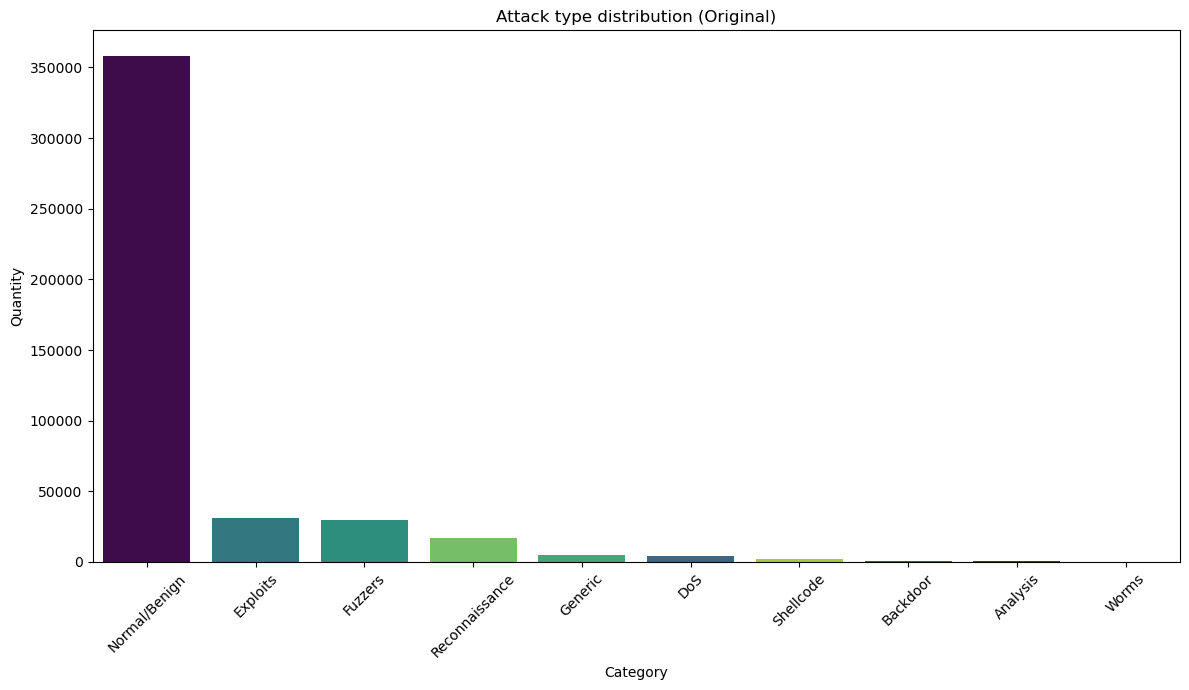

In [15]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

PRE_MAPPING = {
    0: 'Normal/Benign', 1: 'Analysis', 2: 'Backdoor', 3: 'DoS',
    4: 'Exploits', 5: 'Fuzzers', 6: 'Generic', 7: 'Reconnaissance',
    8: 'Shellcode', 9: 'Worms'
}

# ── Load & join ────────────────────────────────────────────────────────────────
data  = pd.read_csv('Dataset/Data.csv')
label = pd.read_csv('Dataset/Label.csv')
joined = pd.concat([data, label], axis=1)

# Replace infinities with NaN and drop them
joined.replace([np.inf, -np.inf], np.nan, inplace=True)
n_dropped = joined.isna().any(axis=1).sum()
joined.dropna(inplace=True)
print(f"Rows dropped (NaN/Inf): {n_dropped:,}")

label_counts_pre = joined['Label'].value_counts()
joined_pre = joined

rare_classes = [1, 2, 3, 6, 8, 9]  # Analysis, Backdoor, DoS, Generic, Shellcode, Worms
joined['Label'] = joined['Label'].apply(lambda x: 10 if x in rare_classes else x)

REINDEX_MAP = {0: 0, 4: 1, 5: 2, 7: 3, 10: 4}
joined['Label'] = joined['Label'].map(REINDEX_MAP)

MAPPING = {
    0: 'Normal/Benign', 
    1: 'Exploits', 
    2: 'Fuzzers', 
    3: 'Reconnaissance', 
    4: 'Rare'
}

# ── Label distribution ─────────────────────────────────────────────────────────
for lbl, count in label_counts_pre.items():
    print(f"  {PRE_MAPPING[lbl]:20s}: {count:>8,}  ({100*count/len(joined_pre):.2f}%)")

tick_labels = [PRE_MAPPING[i] for i in label_counts_pre.index]
plt.figure(figsize=(12, 7))
sns.barplot(x=tick_labels, y=label_counts_pre.values, palette='viridis',
            hue=label_counts_pre.index, legend=False)
plt.title('Attack type distribution (Original)')
plt.xlabel('Category'); plt.ylabel('Quantity')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

  Normal/Benign       :  358,332  (80.00%)
  Exploits            :   30,951  (6.91%)
  Fuzzers             :   29,613  (6.61%)
  Reconnaissance      :   16,735  (3.74%)
  Rare                :   12,284  (2.74%)


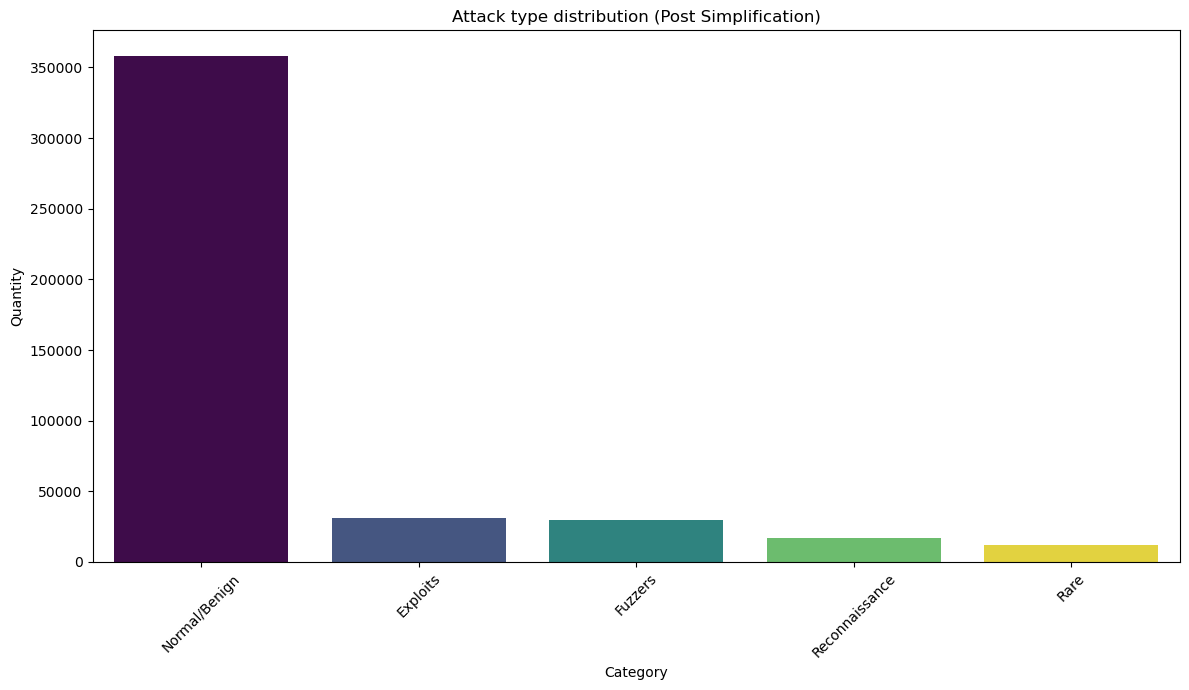

In [16]:
# ── Label distribution ─────────────────────────────────────────────────────────
label_counts = joined['Label'].value_counts()
for lbl, count in label_counts.items():
    print(f"  {MAPPING[lbl]:20s}: {count:>8,}  ({100*count/len(joined):.2f}%)")

tick_labels = [MAPPING[i] for i in label_counts.index]
plt.figure(figsize=(12, 7))
sns.barplot(x=tick_labels, y=label_counts.values, palette='viridis',
            hue=label_counts.index, legend=False)
plt.title('Attack type distribution (Post Simplification)')
plt.xlabel('Category'); plt.ylabel('Quantity')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

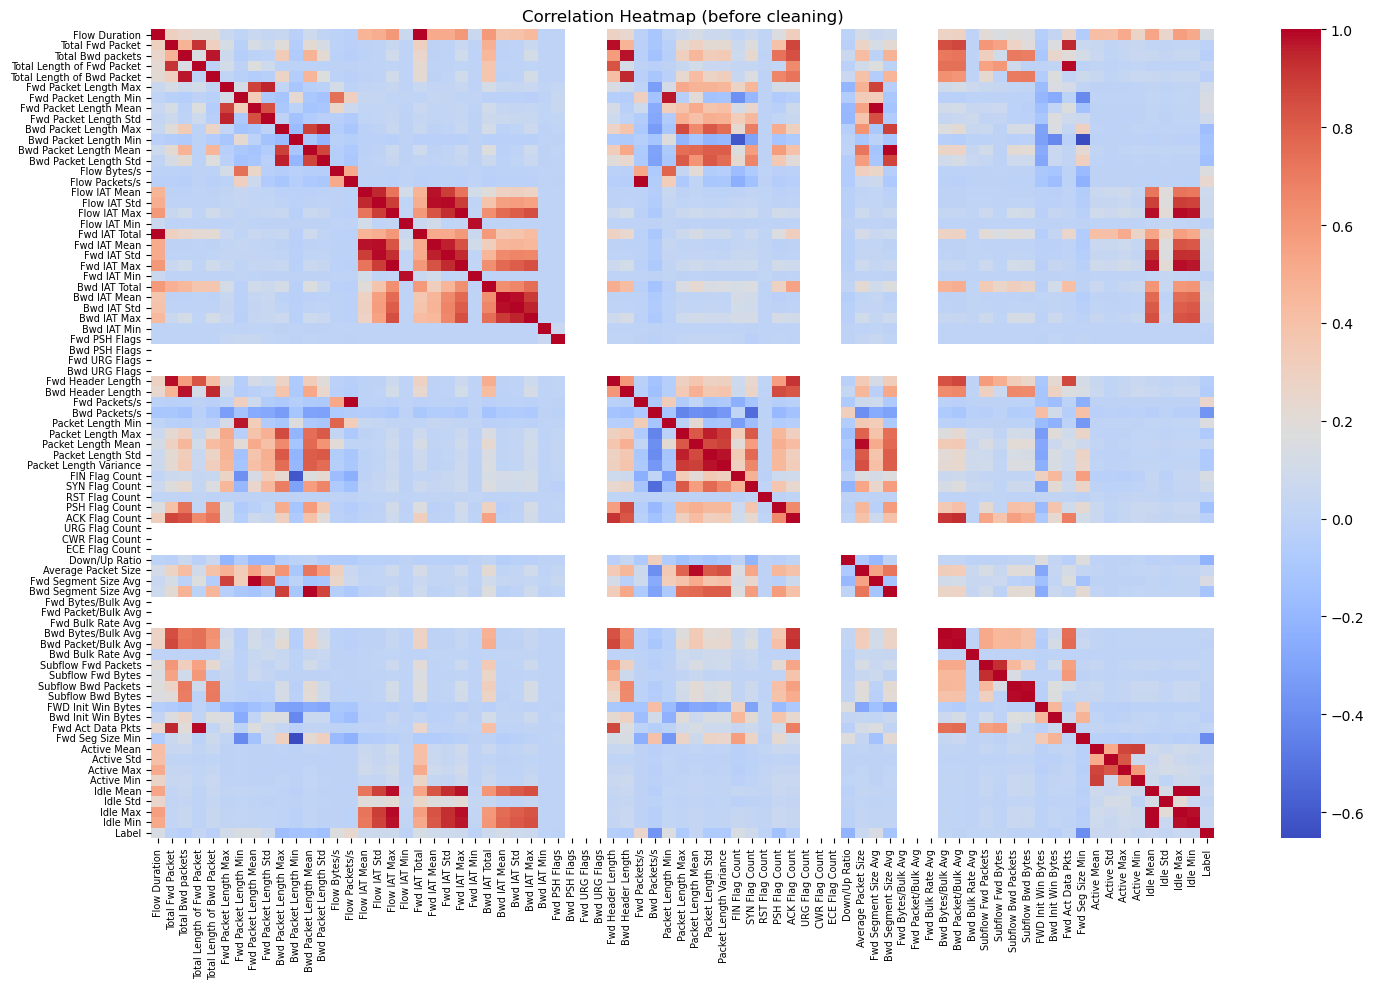

Constant columns removed: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']


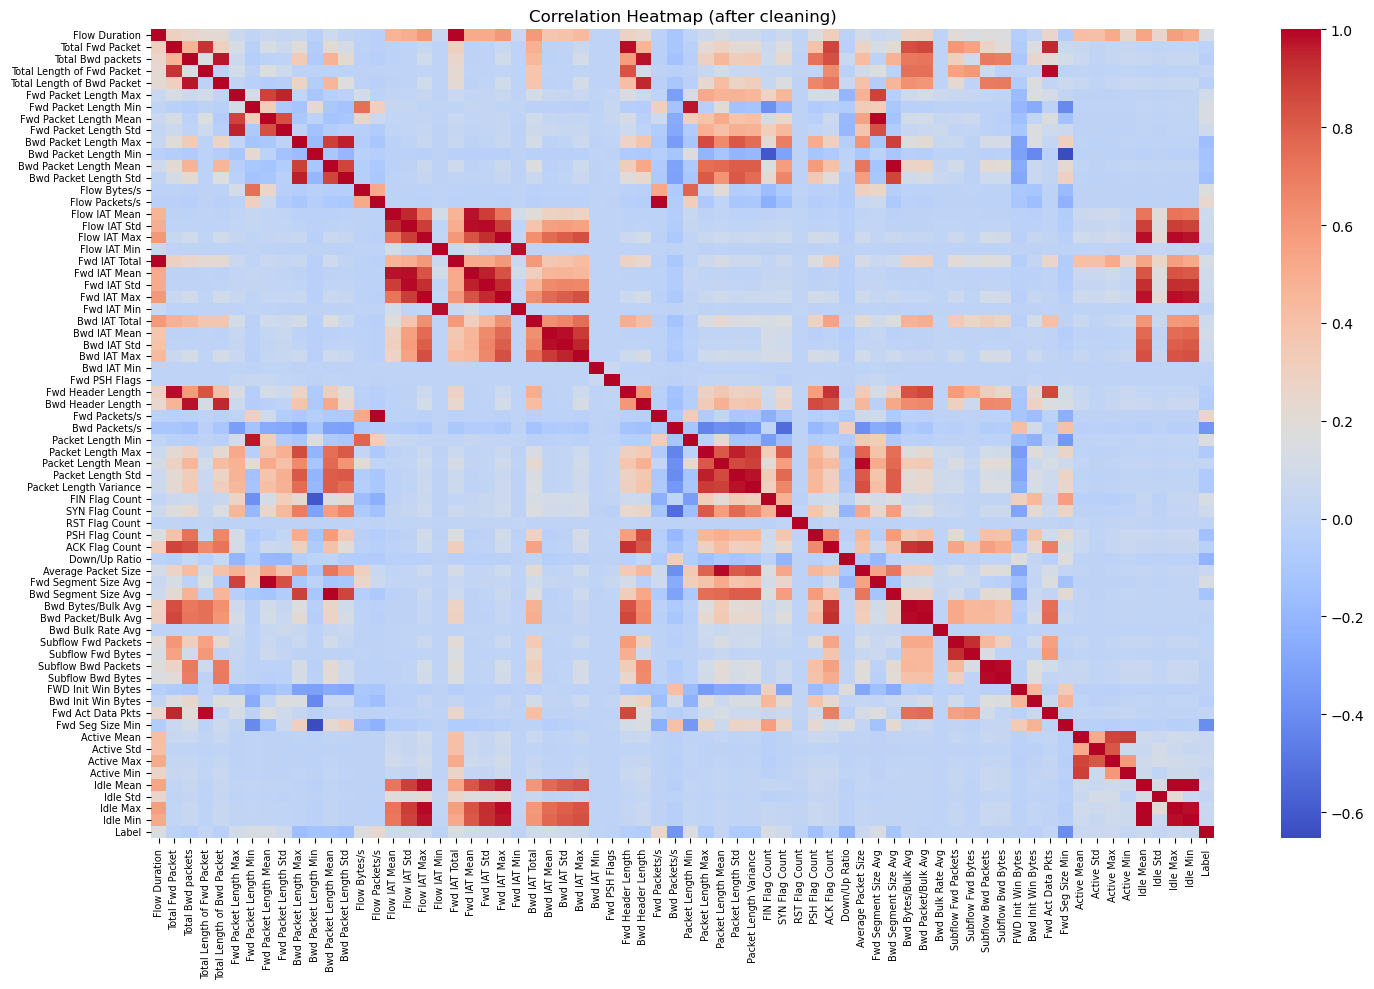

In [17]:
# ── Helper: draw correlation heatmap ─────────────────────────────────────────
def plot_corr(df, title):
    plt.figure(figsize=(15, 10))
    sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
                annot=False, cmap='coolwarm',
                xticklabels=True, yticklabels=True)
    plt.title(title)
    plt.xticks(fontsize=7); plt.yticks(fontsize=7)
    plt.tight_layout(); plt.show()

plot_corr(joined, 'Correlation Heatmap (before cleaning)')

# Drop constant columns (zero variance → useless features)
const_cols = [col for col in joined.columns if joined[col].nunique() <= 1]
print(f"Constant columns removed: {const_cols}")
joined.drop(columns=const_cols, inplace=True)

plot_corr(joined, 'Correlation Heatmap (after cleaning)')

In [24]:
# ── Train / validation / test split ───────────────────────────────────────────
# 70% train | 10% validation (threshold search) | 20% test (final eval)
Y = joined['Label']
X = joined.drop(columns=['Label'])

X_train, X_test,  Y_train, Y_test  = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)
X_train, X_val,   Y_train, Y_val   = train_test_split(
    X_train, Y_train, test_size=0.125, random_state=42, stratify=Y_train)  # 0.125 × 0.8 = 10%

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 313,540 | Val: 44,792 | Test: 89,583


# 2 - Neural Network (Binary: Normal vs Attack)

## 2.1 Training

In [25]:
Y_train_bin = (Y_train > 0).astype(int)
Y_val_bin   = (Y_val   > 0).astype(int)
Y_test_bin  = (Y_test  > 0).astype(int)

# Class weights to handle imbalance
cls_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=Y_train_bin)
dict_weights_nn = dict(enumerate(cls_weights))
print(f"Class weights → Normal: {cls_weights[0]:.2f}, Attack: {cls_weights[1]:.2f}")

nn_model = Sequential([
    Input(shape=(X_train_s.shape[1],)),

    Dense(256, activation='relu', use_bias=False),  # bias redundant before BN
    BatchNormalization(), Dropout(0.2),

    Dense(128, activation='relu', use_bias=False),
    BatchNormalization(), Dropout(0.2),

    Dense(64, activation='relu', use_bias=False),
    BatchNormalization(), Dropout(0.2),

    Dense(32, activation='relu', use_bias=False),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=5e-5),
]

nn_model.fit(
    X_train_s, Y_train_bin,
    epochs=50, batch_size=256,
    validation_data=(X_val_s, Y_val_bin),   # explicit val set, not a split of train
    class_weight=dict_weights_nn,
    callbacks=callbacks, verbose=1
)

Class weights → Normal: 0.62, Attack: 2.50
Epoch 1/50
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9718 - loss: 0.0877 - val_accuracy: 0.9781 - val_loss: 0.0792 - learning_rate: 0.0010
Epoch 2/50
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9777 - loss: 0.0623 - val_accuracy: 0.9781 - val_loss: 0.0758 - learning_rate: 0.0010
Epoch 3/50
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9780 - loss: 0.0601 - val_accuracy: 0.9780 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 4/50
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9780 - loss: 0.0585 - val_accuracy: 0.9785 - val_loss: 0.0698 - learning_rate: 0.0010
Epoch 5/50
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9780 - loss: 0.0576 - val_accuracy: 0.9784 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 6/50
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9782 - loss: 0.0567 - val_accuracy: 0.9786 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 7/50
1225/1225 ━━━━━━━━━━━━

## 2.2 Optimal threshold search (on VALIDATION set — no data leakage)

✓ Threshold found under FP ≤ 2.5% constraint
Threshold        : 0.770
Attack recall    : 99.64%
FP rate (Normal) : 2.39%


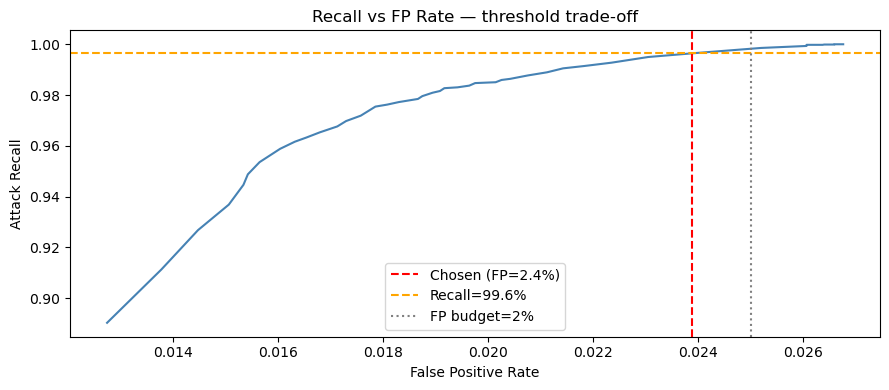

In [26]:
# ── Configurable constraint ────────────────────────────────────────────────────
MAX_FP_RATE = 0.025   # ← ajusta este valor (0.02 = 2%, 0.05 = 5%)

val_probs = nn_model.predict(X_val_s, verbose=0).flatten()
thresholds = np.arange(0.05, 0.95, 0.005)  # finer grid

attack_mask_val = Y_val_bin.values.astype(bool)
preds_matrix    = (val_probs[:, None] > thresholds[None, :]).astype(int)

recalls  = preds_matrix[attack_mask_val].mean(axis=0)
fp_rates = preds_matrix[~attack_mask_val].mean(axis=0)

# Only consider thresholds where FP rate is within budget
valid = fp_rates <= MAX_FP_RATE
if valid.any():
    best_idx       = np.argmax(np.where(valid, recalls, -1))
    best_threshold = thresholds[best_idx]
    best_recall    = recalls[best_idx]
    best_fp_rate   = fp_rates[best_idx]
    print(f"✓ Threshold found under FP ≤ {MAX_FP_RATE*100:.1f}% constraint")
else:
    # Fallback: minimize FP while maximizing recall (weighted trade-off)
    score    = recalls - 3.0 * fp_rates   # ← penaliza FP 3× más que gana recall
    best_idx = np.argmax(score)
    best_threshold = thresholds[best_idx]
    best_recall    = recalls[best_idx]
    best_fp_rate   = fp_rates[best_idx]
    print(f"⚠ No threshold meets FP ≤ {MAX_FP_RATE*100:.1f}%, using best trade-off")

print(f"Threshold        : {best_threshold:.3f}")
print(f"Attack recall    : {best_recall*100:.2f}%")
print(f"FP rate (Normal) : {best_fp_rate*100:.2f}%")

# ── Visual: recall vs FP trade-off curve ──────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(fp_rates, recalls, lw=1.5, color='steelblue')
plt.axvline(best_fp_rate, color='red',    linestyle='--', label=f'Chosen (FP={best_fp_rate*100:.1f}%)')
plt.axhline(best_recall,  color='orange', linestyle='--', label=f'Recall={best_recall*100:.1f}%')
plt.axvline(MAX_FP_RATE,  color='gray',   linestyle=':',  label=f'FP budget={MAX_FP_RATE*100:.0f}%')
plt.xlabel('False Positive Rate'); plt.ylabel('Attack Recall')
plt.title('Recall vs FP Rate — threshold trade-off')
plt.legend(); plt.tight_layout(); plt.show()

## 2.3 Evaluation (on held-out TEST set)

=== Level 1 — Neural Network (Binary) ===

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     71666
      Attack       0.91      1.00      0.95     17917

    accuracy                           0.98     89583
   macro avg       0.96      0.99      0.97     89583
weighted avg       0.98      0.98      0.98     89583

AUC-ROC: 0.9950


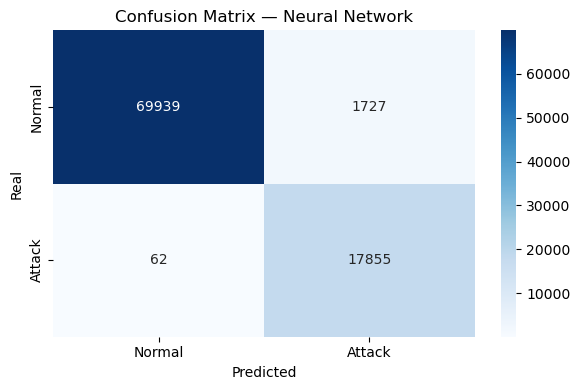

In [27]:
test_probs = nn_model.predict(X_test_s, verbose=0).flatten()
test_preds = (test_probs > best_threshold).astype(int)

print("=== Level 1 — Neural Network (Binary) ===\n")
print(classification_report(Y_test_bin, test_preds, target_names=['Normal', 'Attack']))
print(f"AUC-ROC: {roc_auc_score(Y_test_bin, test_probs):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test_bin, test_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — Neural Network')
plt.ylabel('Real'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

# 3 - Attack Identification (XGBoost Multiclass)

## 3.1 Training

In [28]:
def adaptive_sample_weights(y, base_factor=0.5, boost_below=200, boost_factor=0.85, max_weight=15.0):
    counts = Counter(y)
    max_count = max(counts.values())
    cls_w = {
        cls: min((max_count / cnt) ** (boost_factor if cnt < boost_below else base_factor), max_weight)
        for cls, cnt in counts.items()
    }
    
    print("Class weights applied:")
    for cls, w in sorted(cls_w.items()):
        # Le sumamos 1 a 'cls' para que coincida con los ataques en tu MAPPING (del 1 al 4)
        print(f"  {MAPPING[cls + 1]:20s}: {w:.3f}  (n={counts[cls]:,})")
        
    return np.array([cls_w[cls] for cls in y])

# ── Preparar datos para el Nivel 2 (XGBoost) ──────────────────────────────────
# Filtramos para quedarnos SOLAMENTE con las muestras que son ataques (Y > 0)
mask_train_atk = Y_train > 0
mask_val_atk   = Y_val > 0

X_train_atk = X_train_s[mask_train_atk]
X_val_atk   = X_val_s[mask_val_atk]

# Restamos 1 a las etiquetas para que los 6 ataques vayan del 0 al 5
# (XGBoost exige que las clases empiecen siempre desde el número 0)
Y_train_atk = Y_train[mask_train_atk] - 1
Y_val_atk   = Y_val[mask_val_atk] - 1

sample_weights = adaptive_sample_weights(Y_train_atk)

xgb_model = xgb.XGBClassifier(
    n_estimators=5000,          # más alto — early stopping decide cuándo parar
    learning_rate=0.02,        # un poco más lento → mejor generalización
    max_depth=6,
    min_child_weight=3,        # evita splits en nodos con muy pocas muestras
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.5,            # L2 regularización, ayuda con clases pequeñas
    tree_method='hist',
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_atk, Y_train_atk,
    sample_weight=sample_weights,
    eval_set=[(X_val_atk, Y_val_atk)],
    verbose=50
)
print(f"\nBest iteration: {xgb_model.best_iteration}")

Class weights applied:
  Exploits            : 1.000  (n=21,666)
  Fuzzers             : 1.022  (n=20,729)
  Reconnaissance      : 1.360  (n=11,714)
  Rare                : 1.587  (n=8,599)
[0]	validation_0-mlogloss:1.31757
[50]	validation_0-mlogloss:0.87077
[100]	validation_0-mlogloss:0.73322
[150]	validation_0-mlogloss:0.67113
[200]	validation_0-mlogloss:0.63780
[250]	validation_0-mlogloss:0.61840
[300]	validation_0-mlogloss:0.60630
[350]	validation_0-mlogloss:0.59788
[400]	validation_0-mlogloss:0.59212
[450]	validation_0-mlogloss:0.58722
[500]	validation_0-mlogloss:0.58359
[550]	validation_0-mlogloss:0.58024
[600]	validation_0-mlogloss:0.57747
[650]	validation_0-mlogloss:0.57455
[700]	validation_0-mlogloss:0.57252
[750]	validation_0-mlogloss:0.57045
[800]	validation_0-mlogloss:0.56847
[850]	validation_0-mlogloss:0.56688
[900]	validation_0-mlogloss:0.56542
[950]	validation_0-mlogloss:0.56419
[1000]	validation_0-mlogloss:0.56306
[1050]	validation_0-mlogloss:0.56194
[1100]	validation_0

## 3.2 Full Pipeline Evaluation

NN flagged 19,582 / 89,583 entries as attacks

=== Full Pipeline — Classification Report ===
                precision    recall  f1-score   support

 Normal/Benign       1.00      0.98      0.99     71666
      Exploits       0.82      0.75      0.78      6190
       Fuzzers       0.60      0.92      0.73      5923
Reconnaissance       0.81      0.70      0.75      3347
          Rare       0.70      0.56      0.62      2457

      accuracy                           0.93     89583
     macro avg       0.79      0.78      0.77     89583
  weighted avg       0.95      0.93      0.94     89583



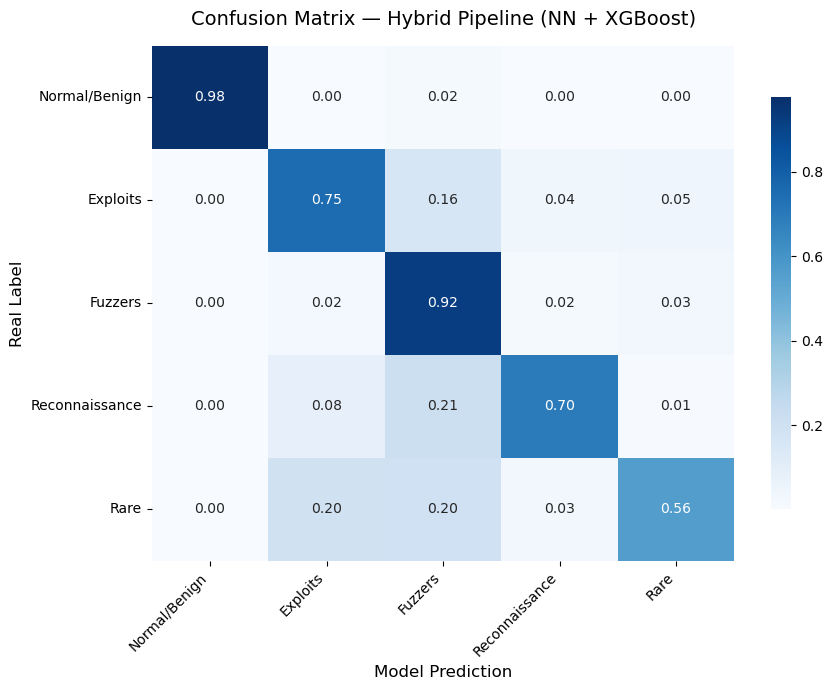

In [29]:
nn_preds_test = (nn_model.predict(X_test_s, verbose=0).flatten() > best_threshold).astype(int)
final_predictions = np.zeros(len(X_test_s), dtype=int)
attack_idx = np.where(nn_preds_test == 1)[0]
print(f"NN flagged {len(attack_idx):,} / {len(X_test_s):,} entries as attacks")

if len(attack_idx):
    # XGBoost ahora devuelve probabilidades para 4 clases de ataque (índices del 0 al 3)
    xgb_proba = xgb_model.predict_proba(X_test_s[attack_idx])   
    
    # Confiamos directamente en la clase con mayor probabilidad (argmax)
    xgb_preds = np.argmax(xgb_proba, axis=1)                    
    
    # Sumamos 1 para que los índices (0 al 3) encajen con nuestro MAPPING de ataques (1 al 4)
    final_predictions[attack_idx] = xgb_preds + 1

# >>> CAMBIO AQUÍ: Tienes 5 clases en total (0, 1, 2, 3, 4), así que usamos range(5) <<<
target_names = [MAPPING[i] for i in range(5)]

print("\n=== Full Pipeline — Classification Report ===")
print(classification_report(Y_test, final_predictions, target_names=target_names))

# ── Visualización: Matriz de Confusión del Pipeline Completo ──
plt.figure(figsize=(9, 7))  # Tamaño ajustado para tus 5 clases actuales
cm_norm = confusion_matrix(Y_test, final_predictions, normalize='true')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'shrink': 0.8})  # Hace que la barra de color sea un poco más elegante

plt.title('Confusion Matrix — Hybrid Pipeline (NN + XGBoost)', fontsize=14, pad=15)
plt.ylabel('Real Label', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)

# ha='right' ancla el texto rotado para que quede perfectamente alineado bajo su columna
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

# 4 - Saving Models & Artefacts

In [ ]:
BASE = 'backend/models'

joblib.dump(scaler, f'{BASE}/scaler.pkl')
print("Saved: scaler.pkl")

with open(f'{BASE}/feature_names.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f)
print("Saved: feature_names.json")

with open(f'{BASE}/mapping.json', 'w') as f:
    json.dump({str(k): v for k, v in MAPPING.items()}, f)
print("Saved: mapping.json")

with open(f'{BASE}/threshold.json', 'w') as f:
    json.dump({'binary_threshold': float(best_threshold)}, f)
print("Saved: threshold.json")

nn_model.save(f'{BASE}/nn_model.keras')
print("Saved: nn_model.keras")

xgb_model.save_model(f'{BASE}/xgb_model.json')
print("Saved: xgb_model.json")